# GPT1: Improving Language Understanding by Generative Pre-Training

It demonstrates that large gains on diverse tasks such as textual entailment, question answering, semantic similarity assessment, 
and document classification can be realized by generative pre-training of a language model on a diverse corpus of unlabeled text, 
followed by discriminative fine-tuning on each specific task.

# Import Libraries

In [33]:
import datasets
import re
import ftfy
import os
import spacy
from collections import Counter,defaultdict
import multiprocessing as mp
import tqdm
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!spacy download en_core_web_md

# Setting important global variables

In [35]:
cpu_cores = os.cpu_count()
end_of_word_token = "</w>"

# Generative Pre-Training

## Data Prep

### Loading saving and reloading the dataset
We use the BooksCorpus dataset for training the language model. It contains over 7,000 unique unpublished 
books from a variety of genres including Adventure, Fantasy, and Romance. Crucially, it contains long stretches of contiguous 
text, which allows the generative model to learn to condition on long-range information.

In [4]:
# bookscorpus_dataset = datasets.load_dataset("bookcorpus")["train"]
# bookscorpus_dataset.save_to_disk("datasets/bookscorpus")
bookscorpus_dataset = datasets.load_from_disk("datasets/bookscorpus")
len(bookscorpus_dataset), bookscorpus_dataset[0]

(74004228,
 {'text': 'usually , he would be tearing around the living room , playing with his toys .'})

### Cleaning, Saving and Loading cleaned dataset
We use the ftfy library to clean the raw text in BooksCorpus, standardize some punctuation and
whitespace

In [5]:
def clean_text(sentence):
    """
    - uses ftfy library to clean the raw text
    - fixes some issues the spacy tokenizer had on books corpus
    - also does some whitespace standardization
    """
    # print(sentence)
    text = str(sentence["text"])
    text = ftfy.fix_text(text)
    text = text.replace('—', '-')
    text = text.replace('–', '-')
    text = text.replace('―', '-')
    text = text.replace('…', '...')
    text = text.replace('´', "'")
    text = re.sub('''(-+|~+|!+|"+|;+|\?+|\++|,+|\)+|\(+|\\+|\/+|\*+|\[+|\]+|}+|{+|\|+|_+)''', r' \1 ', text)
    text = re.sub('\s*\n\s*', ' \n ', text)
    text = re.sub('[^\S\n]+', ' ', text)
    text = text.strip()
    sentence["text"] = text
    return sentence

In [6]:
# bookscorpus_dataset = bookscorpus_dataset.map(clean_text,num_proc=cpu_cores)
# bookscorpus_dataset.save_to_disk("datasets/bookscorpus_cleaned")
bookscorpus_dataset = datasets.load_from_disk("datasets/bookscorpus_cleaned")["text"]
len(bookscorpus_dataset), bookscorpus_dataset[0]

(74004228,
 'usually , he would be tearing around the living room , playing with his toys .')

### Get and save wordcounts(aka vocab)

Uses the spaCy tokenizer to split text. Word counts are important for the byte-pair encoding
- full dataset took 2hrs 20 minutes to count

In [11]:
nlp = spacy.load("en_core_web_md",disable=['parser', 'ner', 'textcat'])

word_counts = Counter()
def split_dataset(size):
    unit = size//cpu_cores
    chunks = []
    for i in range(0,size,unit):
        chunks.append((i,i+unit))
    return chunks

def spacy_tokenize(doc):
    return [" ".join(token.text)+" "+end_of_word_token for token in doc]

def count_words_chunk(chunk):
    start,end = chunk
    local_counts = Counter()
    for doc in tqdm.tqdm(nlp.pipe(bookscorpus_dataset[start:end]),ncols=100):
        words = spacy_tokenize(doc)
        local_counts.update(words)
    return local_counts

with mp.Pool(processes=cpu_cores) as pool:
    chunks = split_dataset(len(bookscorpus_dataset))  # Implement a way to split the dataset
    chunk_results = pool.map(count_words_chunk, chunks)

    for result in chunk_results:
        word_counts += result

with open("word_counts.json","w") as f:
    json.dump(word_counts,f)

25000it [01:12, 343.36it/s]
25000it [01:14, 335.58it/s]
25000it [01:16, 327.65it/s]
25000it [01:16, 326.72it/s]


In [3]:
with open("word_counts.json", "r") as f:
    word_counts = json.load(f)
len(word_counts),word_counts["h e </w>"]

(688442, 13870628)

#### visualize most common and least common words

<Axes: >

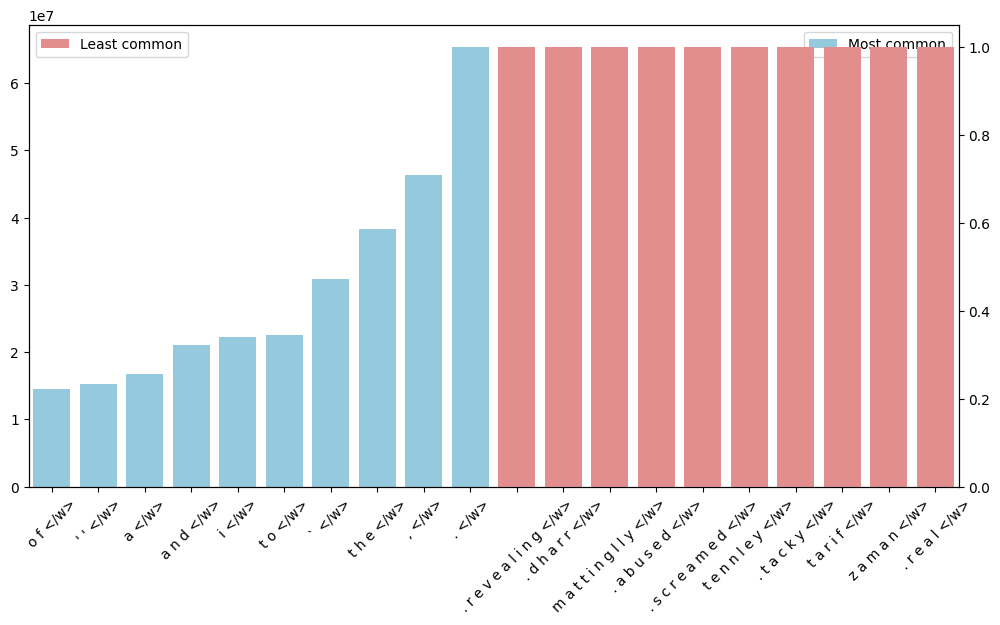

In [32]:
sorted_counts = sorted(word_counts.items(), key=lambda item: item[1])
mc = sorted_counts[-10:]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45)
sns.barplot(x=[w[0] for w in mc],y=[w[1] for w in mc],color="skyblue",label="Most common")
lc = sorted_counts[:10]
ax2 = plt.twinx()
plt.xticks(rotation=45)
sns.barplot(x=[w[0] for w in lc],y=[w[1] for w in lc],color="lightcoral",label="Least common")

### Train BPE

We used a bytepair encoding (BPE) vocabulary with 40,000 merges. BPE algorithm explained in the (paper)[https://arxiv.org/pdf/1508.07909]

- full bpe training took 10 hrs

In [42]:
num_merges = 40000

with open("word_counts.json", "r") as f:
    word_counts = json.load(f)
if os.path.exists("bpe.json"):
    with open("bpe.json", "r") as f:
        bpe = list(json.load(f).keys())
else:
    bpe = sorted(list(set(" ".join(word_counts.keys()).split())))


def get_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pairs[symbols[i],symbols[i+1]] += freq
    return pairs


def merge_vocab(pair, v_in):
    v_out = {}
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out


for i in tqdm.tqdm(range(100),ncols=100):
    pairs = get_stats(word_counts)
    best = max(pairs, key=pairs.get)
    word_counts = merge_vocab(best, word_counts)
    if not (len(best[0]) == 1 and best[1] == end_of_word_token):
        bpe.append(" ".join(best))
    if i%10 == 0:
        with open("bpe.json","w") as f:
            json.dump({t:i for i,t in enumerate(bpe)},f)
        with open("word_counts.json","w") as f:
            json.dump(word_counts,f)

100%|█████████████████████████████████████████████████████████████| 100/100 [04:37<00:00,  2.78s/it]
